<a href="https://colab.research.google.com/github/maxzaragoza2a/deeplearning-benchmark-project/blob/main/Dataset_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

base_path = '/content/drive/MyDrive/Projet DeepLearning Benchmark/ds_FSL'

train_path = os.path.join(base_path, 'train')
valid_path = os.path.join(base_path, 'valid')
test_path  = os.path.join(base_path, 'test')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train exists: True
Valid exists: True
Test exists: True


In [ ]:
!pip install -q matplotlib seaborn pillow pandas numpy

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import random

sns.set_theme(style="whitegrid")
%matplotlib inline

In [ ]:
def collect_stats(split_path, split_name):
    classes = sorted(os.listdir(split_path))
    data = []
    for cls in classes:
        cls_path = os.path.join(split_path, cls)
        if not os.path.isdir(cls_path):
            continue
        images = [f for f in os.listdir(cls_path)
                   if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
        data.append({
            'split': split_name,
            'class': cls,
            'num_images': len(images)
        })
    return pd.DataFrame(data)

df_train = collect_stats(train_path, 'train')
df_valid = collect_stats(valid_path, 'valid')
df_test  = collect_stats(test_path, 'test')

df_all = pd.concat([df_train, df_valid, df_test], ignore_index=True)
df_all.head()

,split,class,num_images
0,train,Aedes aegypti,18
1,train,Aedes albopictus,79
2,train,Aedes berlandi,1
3,train,Aedes cantans,3
4,train,Aedes caspius,2


In [ ]:
print("Number of classes per split:")
print(df_all.groupby('split')['class'].nunique())

print("\nTotal images per split:")
print(df_all.groupby('split')['num_images'].sum())

print("\nImages-per-class statistics per split:")
print(df_all.groupby('split')['num_images'].describe())

Number of classes per split:
split
test     129
train    129
valid    129
Name: class, dtype: int64

Total images per split:
split
test     1821
train    1818
valid    1819
Name: num_images, dtype: int64

Images-per-class statistics per split:
       count       mean        std  min  25%  50%  75%    max
split                                                        
test   129.0  14.116279  26.723886  1.0  2.0  3.0  9.0  205.0
train  129.0  14.093023  26.404735  1.0  2.0  4.0  8.0  202.0
valid  129.0  14.100775  26.642554  1.0  2.0  3.0  9.0  203.0


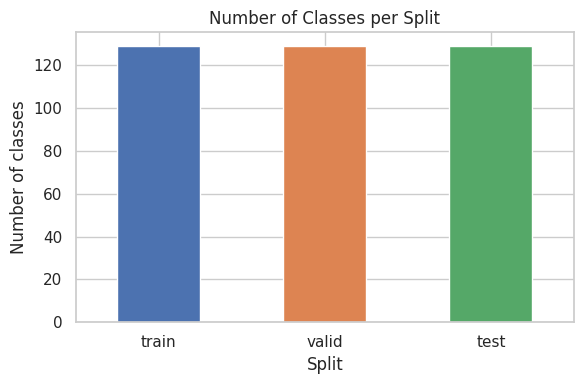

In [ ]:
class_counts = df_all.groupby('split')['class'].nunique().reindex(['train', 'valid', 'test'])

plt.figure(figsize=(6, 4))
class_counts.plot(kind='bar', color=['#4C72B0', '#DD8452', '#55A868'])
plt.title('Number of Classes per Split')
plt.ylabel('Number of classes')
plt.xlabel('Split')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

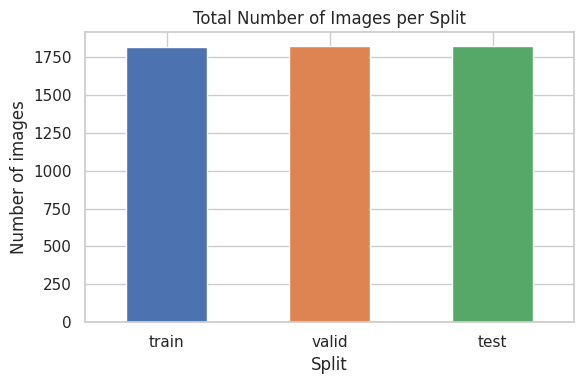

In [ ]:
image_counts = df_all.groupby('split')['num_images'].sum().reindex(['train', 'valid', 'test'])

plt.figure(figsize=(6, 4))
image_counts.plot(kind='bar', color=['#4C72B0', '#DD8452', '#55A868'])
plt.title('Total Number of Images per Split')
plt.ylabel('Number of images')
plt.xlabel('Split')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
train_classes = set(df_train['class'])
valid_classes = set(df_valid['class'])
test_classes  = set(df_test['class'])

print("Train ∩ Valid ∩ Test (common classes):", len(train_classes & valid_classes & test_classes))
print("Are train/valid/test class sets identical?", train_classes == valid_classes == test_classes)

Train ∩ Valid ∩ Test (common classes): 129
Are train/valid/test class sets identical? True


In [ ]:
df_train_sorted = df_train.sort_values('num_images', ascending=False).reset_index(drop=True)
df_train_sorted

,split,class,num_images
0,train,Glossina palpalis palpalis,202
1,train,Glossina fuscipes fuscipes,99
2,train,Culex neavei,87
3,train,Aedes albopictus,79
4,train,Phlebotomus sergenti,75
...,...,...,...
124,train,Auchmeromya luteola,1
125,train,Lucilia cuprina,1
126,train,Lucilia infernalis,1
127,train,Glossina swynnertoni,1


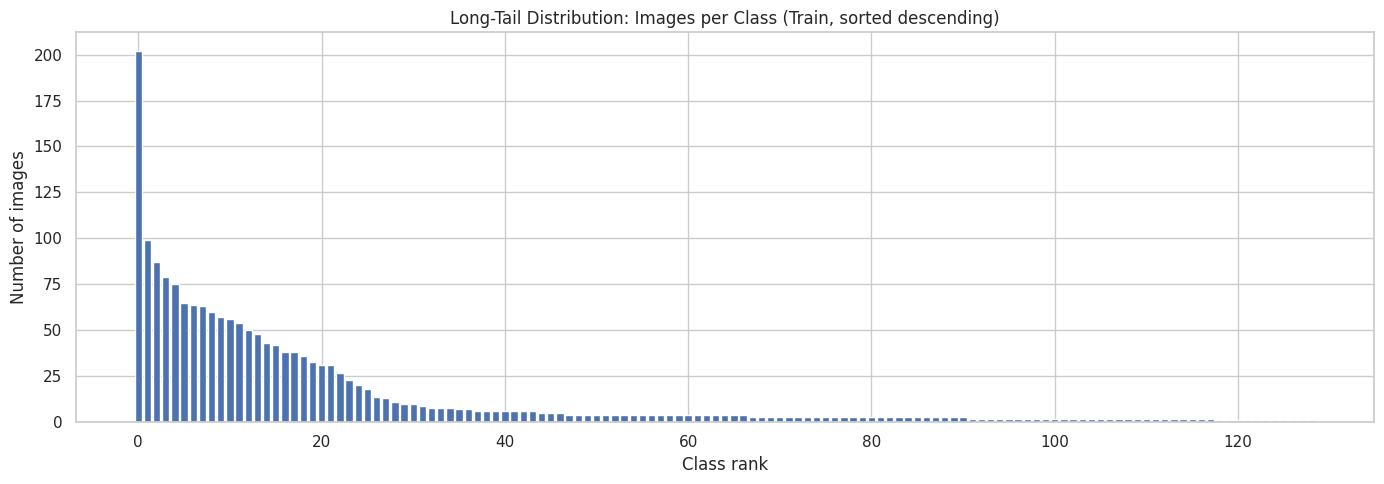

In [ ]:
train_sorted = df_train.sort_values('num_images', ascending=False).reset_index(drop=True)

plt.figure(figsize=(14, 5))
plt.bar(range(len(train_sorted)), train_sorted['num_images'], color='#4C72B0')
plt.title('Long-Tail Distribution: Images per Class (Train, sorted descending)')
plt.xlabel('Class rank')
plt.ylabel('Number of images')
plt.tight_layout()
plt.show()

The training set follows a classic long-tail distribution.
A single dominant class holds approximately 200 images, roughly double the
second-ranked class (about 100). Image counts drop sharply within the first
20 classes, and from rank 40 onward, the vast majority of classes have fewer
than 10 images each, several with just 1-3. This is a severe class imbalance
problem. Standard supervised training would be biased toward the few "head"
classes. For few-shot learning, this means a large fraction of classes
cannot support even modest K-shot configurations (e.g., 5-shot plus query).

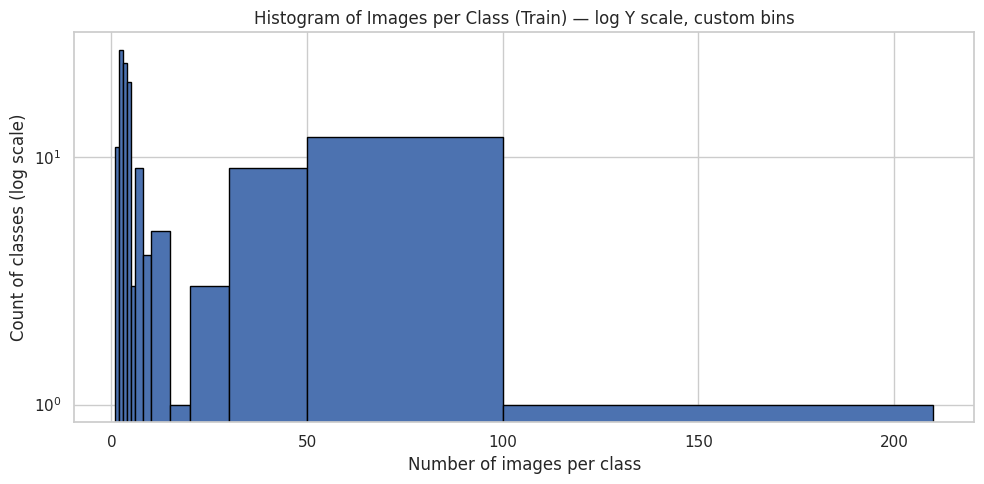

In [ ]:
plt.figure(figsize=(10, 5))
bins = [1, 2, 3, 4, 5, 6, 8, 10, 15, 20, 30, 50, 100, 210]
plt.hist(df_train['num_images'], bins=bins, color='#4C72B0', edgecolor='black')
plt.yscale('log')
plt.title('Histogram of Images per Class (Train) — log Y scale, custom bins')
plt.xlabel('Number of images per class')
plt.ylabel('Count of classes (log scale)')
plt.tight_layout()
plt.show()

We observe that roughly
60+ classes fall in the 1–5 images range (the tallest bars), a smaller group
sits in the 5–15 range, and only a handful of classes reach into the 50–200+
range.

   min_images_required  num_eligible_classes
0                    1                   129
1                    2                   118
2                    3                    91
3                    5                    47
4                    6                    44
5                   10                    31
6                   16                    26
7                   20                    25
8                   30                    22


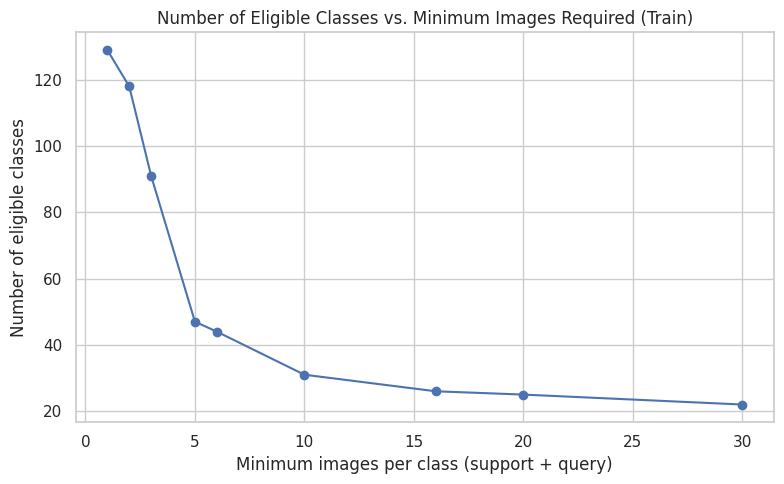

In [ ]:
thresholds = [1, 2, 3, 5, 6, 10, 16, 20, 30]
feasibility = []
for t in thresholds:
    n_classes = (df_train['num_images'] >= t).sum()
    feasibility.append({'min_images_required': t, 'num_eligible_classes': n_classes})

df_feasibility = pd.DataFrame(feasibility)
print(df_feasibility)

plt.figure(figsize=(8, 5))
plt.plot(df_feasibility['min_images_required'], df_feasibility['num_eligible_classes'], marker='o')
plt.title('Number of Eligible Classes vs. Minimum Images Required (Train)')
plt.xlabel('Minimum images per class (support + query)')
plt.ylabel('Number of eligible classes')
plt.grid(True)
plt.tight_layout()
plt.show()

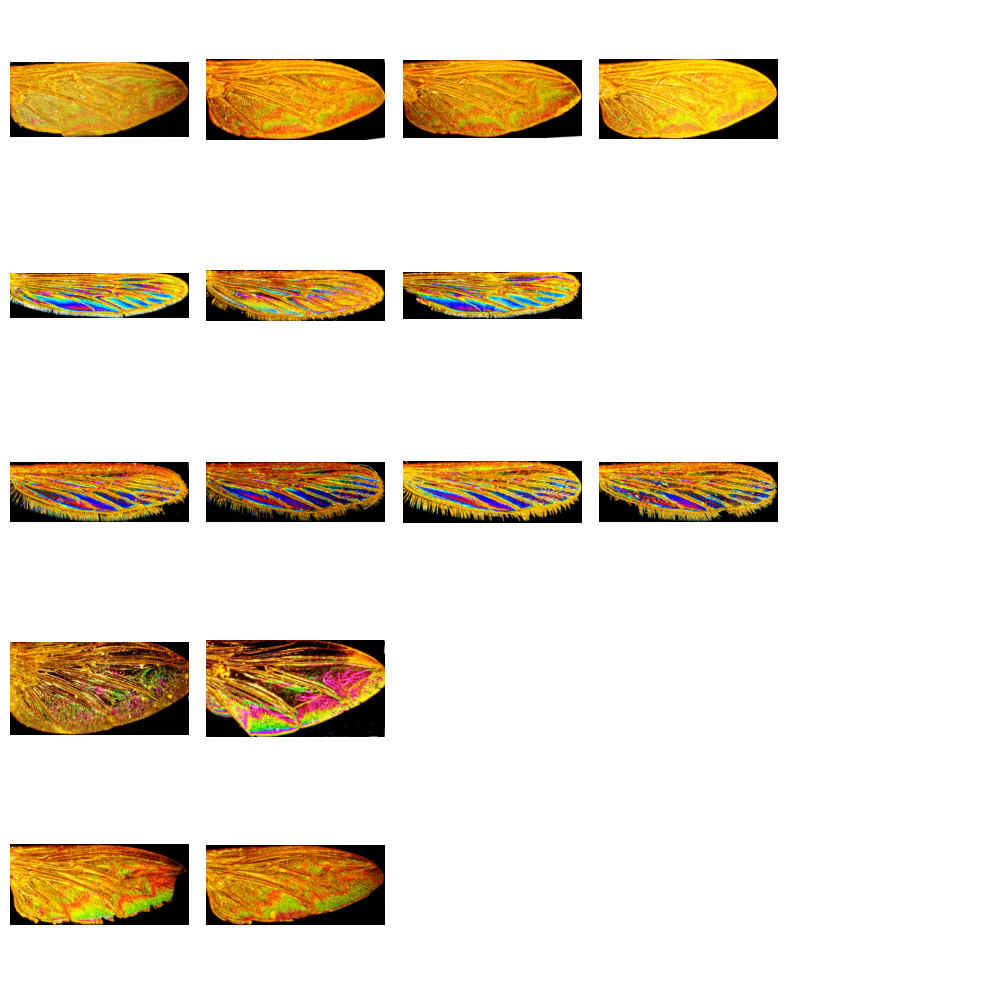

In [ ]:
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True  # allow loading truncated images instead of crashing

def show_class_examples(split_path, classes_to_show, n_images=5):
    fig, axes = plt.subplots(len(classes_to_show), n_images, figsize=(n_images*2, len(classes_to_show)*2))
    for row, cls in enumerate(classes_to_show):
        cls_path = os.path.join(split_path, cls)
        images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        sample_imgs = random.sample(images, min(n_images, len(images)))
        for col in range(n_images):
            ax = axes[row, col] if len(classes_to_show) > 1 else axes[col]
            if col < len(sample_imgs):
                try:
                    img = Image.open(os.path.join(cls_path, sample_imgs[col]))
                    img.load()  # force full load to catch corrupt files here
                    ax.imshow(img)
                except Exception as e:
                    ax.text(0.5, 0.5, 'corrupt', ha='center', va='center', fontsize=8)
            ax.axis('off')
            if col == 0:
                ax.set_ylabel(cls, rotation=0, labelpad=60, fontsize=9)
    plt.tight_layout()
    plt.show()

sample_classes = random.sample(list(train_classes), 5)
show_class_examples(train_path, sample_classes, n_images=5)

            width      height
count   200.00000  200.000000
mean   1275.78500  526.225000
std     219.54125  172.676548
min     613.00000  189.000000
25%    1129.00000  391.000000
50%    1295.00000  520.000000
75%    1452.00000  654.500000
max    1600.00000  992.000000

Aspect ratio (width/height) stats:
count    200.000000
mean       2.595563
std        0.610089
min        1.560484
25%        2.101054
50%        2.319992
75%        3.159075
max        3.974026
dtype: float64


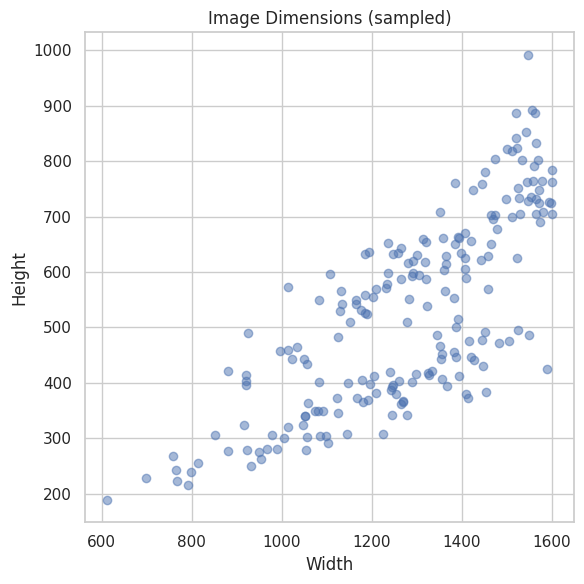

In [ ]:
def collect_image_dims(split_path, sample_size=200):
    all_files = []
    for cls in os.listdir(split_path):
        cls_path = os.path.join(split_path, cls)
        if os.path.isdir(cls_path):
            for f in os.listdir(cls_path):
                if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                    all_files.append(os.path.join(cls_path, f))

    sample_files = random.sample(all_files, min(sample_size, len(all_files)))
    dims = []
    for f in sample_files:
        try:
            with Image.open(f) as img:
                dims.append({'width': img.width, 'height': img.height, 'mode': img.mode})
        except Exception:
            continue
    return pd.DataFrame(dims)

df_dims = collect_image_dims(train_path)
print(df_dims.describe())
print("\nAspect ratio (width/height) stats:")
print((df_dims['width'] / df_dims['height']).describe())

plt.figure(figsize=(6,6))
plt.scatter(df_dims['width'], df_dims['height'], alpha=0.5)
plt.title('Image Dimensions (sampled)')
plt.xlabel('Width')
plt.ylabel('Height')
plt.tight_layout()
plt.show()